In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

dt = 0.01
t = np.arange(0, 1000 + dt, dt)
a = 0.5
b = 0.025
c = 0.5
d = 0.005

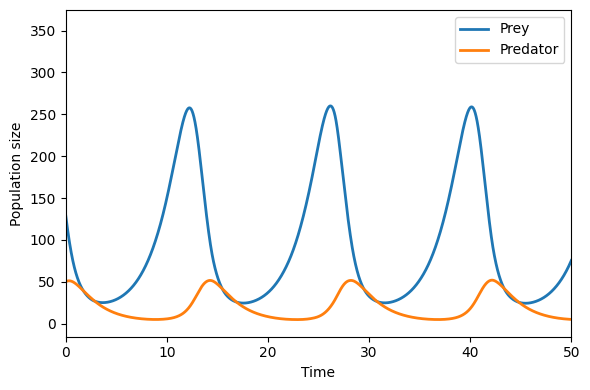

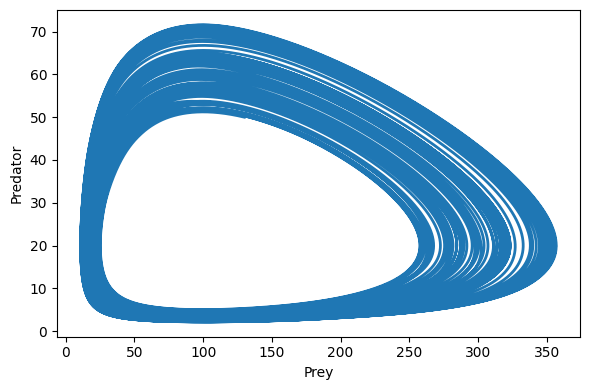

In [2]:
# Lotka-Volterra basic
x0_lv = [130, 50]

def lotka_volterra(t, x):
    return [a*x[0] - b*x[0]*x[1],
           -c*x[1] + d*x[0]*x[1]]

sol = solve_ivp(lotka_volterra, [t[0], t[-1]], x0_lv, t_eval=t)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sol.t, sol.y[0], linewidth=2, label='Prey')
ax.plot(sol.t, sol.y[1], linewidth=2, label='Predator')
ax.set_xlabel('Time'); ax.set_ylabel('Population size')
ax.legend(); ax.set_xlim([0, 50])
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sol.y[0], sol.y[1], linewidth=2)
ax.set_xlabel('Prey'); ax.set_ylabel('Predator')
plt.tight_layout(); plt.show()

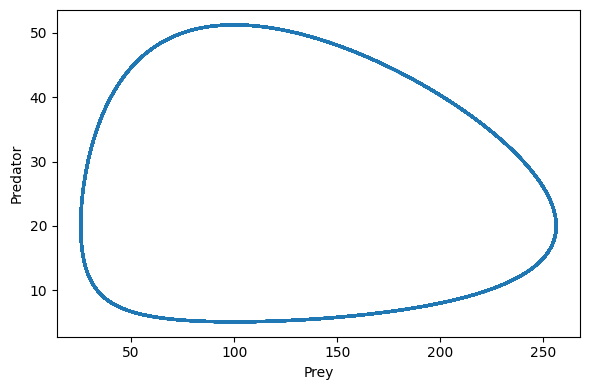

In [4]:
# High accuracy tolerances
sol_hq = solve_ivp(lotka_volterra, [t[0], t[-1]], x0_lv, t_eval=t, rtol=1e-10, atol=1e-11)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sol_hq.y[0], sol_hq.y[1], linewidth=2)
ax.set_xlabel('Prey'); ax.set_ylabel('Predator')
plt.tight_layout(); plt.show()

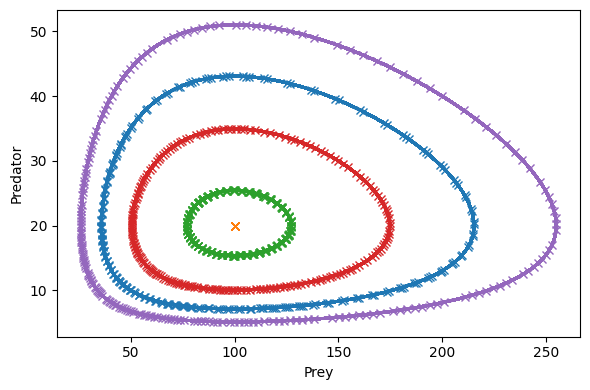

In [5]:
# Ensemble of initial conditions
x0_ensemble = [[50, 10], [100, 20], [110, 25], [150, 30], [200, 40]]

fig, ax = plt.subplots(figsize=(6, 4))
for x0_i in x0_ensemble:
    sol_i = solve_ivp(lotka_volterra, [t[0], t[-1]], x0_i, t_eval=t, rtol=1e-10, atol=1e-11)
    ax.plot(sol_i.y[0], sol_i.y[1], '-x', linewidth=2, markevery=500)
ax.set_xlabel('Prey'); ax.set_ylabel('Predator')
plt.tight_layout(); plt.show()

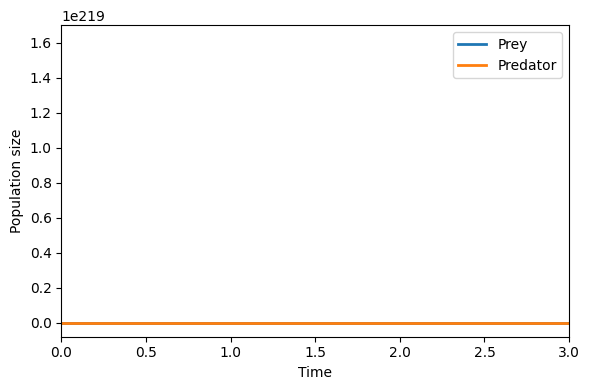

In [6]:
# Decoupled system (no interaction)
def lotka_volterra_no_interaction(t, x):
    return [a * x[0],
           -c * x[1]]

sol_dec = solve_ivp(lotka_volterra_no_interaction, [t[0], t[-1]], x0_lv, t_eval=t)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sol_dec.t, sol_dec.y[0], linewidth=2, label='Prey')
ax.plot(sol_dec.t, sol_dec.y[1], linewidth=2, label='Predator')
ax.set_xlabel('Time'); ax.set_ylabel('Population size')
ax.legend(); ax.set_xlim([0, 3])
plt.tight_layout(); plt.show()